Copyright © 2024, Andrea Mastropietro. All rights reserved.

This code is licensed under the MIT License.

See the LICENSE file in the project root for more information.

## Shapley value distribution analysis
This notebook contains code for the analysis of the Shapley value distributions and their statistical significance.

In [1]:
import os
# os.environ["http_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"
# os.environ["https_proxy"] = "http://web-proxy.informatik.uni-bonn.de:3128"

Import libraries

In [ ]:
# System and path management
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Configuration and YAML
import yaml

# Scientific computing and statistics
import numpy as np
import torch
from scipy.spatial.distance import directed_hausdorff
import scipy.stats as stats
from scipy.stats import spearmanr

# Data handling
import pandas as pd

# Plotting and visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Project-specific imports
from src.difflinker.lightning import DDPM
from src.difflinker.datasets import get_dataloader

SyntaxError: invalid syntax (315446523.py, line 13)

In [ ]:
EXPLANATIONS_FOLDER = "../results/explanations/zinc_final_test/"

with open('../config.yml', 'r') as file:
    config = yaml.safe_load(file)

checkpoint = "../" + config['CHECKPOINT']
DATA_FOLDER = "../" + config['DATA_FOLDER']
DATASET_NAME = config['DATASET_NAME']
keep_frames = int(config['KEEP_FRAMES'])
device = config['DEVICE'] if torch.cuda.is_available() else 'cpu'
SEED = int(config['SEED'])
NUM_SAMPLES = int(config['NUM_SAMPLES'])
SAVE_PLOTS = False
SEED_LIST = [42,1240,14085]

model = DDPM.load_from_checkpoint(checkpoint, map_location=device)

model.val_data_prefix = DATASET_NAME

print(f"Running device: {device}")

model.data_path = DATA_FOLDER

model = model.eval().to(device)
model.setup(stage='val')
dataloader = get_dataloader(
    model.val_dataset,
    batch_size=1
)

c:\Users\Mastro\anaconda3\envs\diff_explainer\lib\site-packages\lightning_fabric\utilities\cloud_io.py:57: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
Lightning automatically upgraded your

Running device: cuda:0


Load data samples for fragment, linker and anchor indices

In [ ]:
data_list = []
sampled = 0
data_dict = {}
for data in dataloader:
    if sampled < NUM_SAMPLES:
        data_list.append(data)
        sampled += 1

for i in range(len(data_list)):
    data_dict[i] = {}
    data_dict[i]["fragment_mask"] = data_list[i]['fragment_mask'].squeeze(0)
    data_dict[i]["linker_mask"] = data_list[i]['linker_mask'].squeeze(0)
    data_dict[i]["anchors"] = data_list[i]['anchors'].squeeze(0)

Read coordinates of generated linkers

In [ ]:
for seed in SEED_LIST:
    for i in range(NUM_SAMPLES):
        with open(f"{EXPLANATIONS_FOLDER}explanations_seed_{str(seed)}/mapping/graphs/{i}/{i}_0_.xyz", "r") as f:
            num_atoms = int(f.readline().strip())
            f.readline()
            positions = []*num_atoms
            for line in f:
                row = line.strip().split(" ")[1:]
                coords = [float(x) for x in row]
                positions.append(coords)
            dict_key_name = f"positions_{seed}"
            data_dict[i][dict_key_name] = positions

In [ ]:
#compute average hausdorff distance over the seeds for each sample
for i in range(NUM_SAMPLES):
    hausdorff_distances = []
    linker_coords_list = []
    for seed in SEED_LIST:
        coords = np.array(data_dict[i][f"positions_{seed}"])
        linker_mask = data_dict[i]["linker_mask"].cpu().numpy().squeeze().astype(bool)
        linker_coords = coords[linker_mask]
        linker_coords_list.append(linker_coords)
    
    # Compute Hausdorff distances for all possible pairs
    for j in range(len(linker_coords_list)):
        for k in range(j+1, len(linker_coords_list)):
            # Compute directed Hausdorff distances in both directions
            h1 = directed_hausdorff(linker_coords_list[j], linker_coords_list[k])[0]
            h2 = directed_hausdorff(linker_coords_list[k], linker_coords_list[j])[0]
            # Hausdorff distance is the maximum of the two directed distances
            hausdorff_distance = max(h1, h2)
            hausdorff_distances.append(hausdorff_distance)
    
    data_dict[i]["average_hausdorff_distance"] = sum(hausdorff_distances)/len(hausdorff_distances)

In [ ]:
#print the samples for whihch the average hausdorff distance is less than 1
samples_with_similar_linkers = []
samples_with_different_linkers = []

for i in range(NUM_SAMPLES):
    if data_dict[i]['average_hausdorff_distance'] < 1:
        samples_with_similar_linkers.append(i)
        
    if data_dict[i]['average_hausdorff_distance'] > 3:
        samples_with_different_linkers.append(i)
        

Read Shapley values for similar linkers

In [ ]:
#load shapley values
shapley_values_similar_dict = {}
shapley_values_all_dict = {}
shapley_values_different_dict = {}
for i in range(NUM_SAMPLES):
    shapley_values_all_dict[i] = []
    if i in samples_with_similar_linkers:
        shapley_values_similar_dict[i] = []
    if i in samples_with_different_linkers:
        shapley_values_different_dict[i] = []
    for seed in SEED_LIST:
        shapley_values_seed = []
        with open(f"{EXPLANATIONS_FOLDER}explanations_seed_{str(seed)}/shapley_values/shapley_values_atoms_{i}.txt", "r") as f:
            f.readline()
            f.readline()
            
            for line in f:
                if line == "\n":
                    break
                row = line.strip().split(",")
                shapley_values_seed.append(float(row[1]))
        shapley_values_all_dict[i].append(shapley_values_seed)
        if i in samples_with_similar_linkers:
            shapley_values_similar_dict[i].append(shapley_values_seed)
        if i in samples_with_different_linkers:
            shapley_values_different_dict[i].append(shapley_values_seed)

Plot Shapley value distribution for similar linkers

C:\Users\Mastro\AppData\Local\Temp\ipykernel_30736\3519449167.py:21: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)


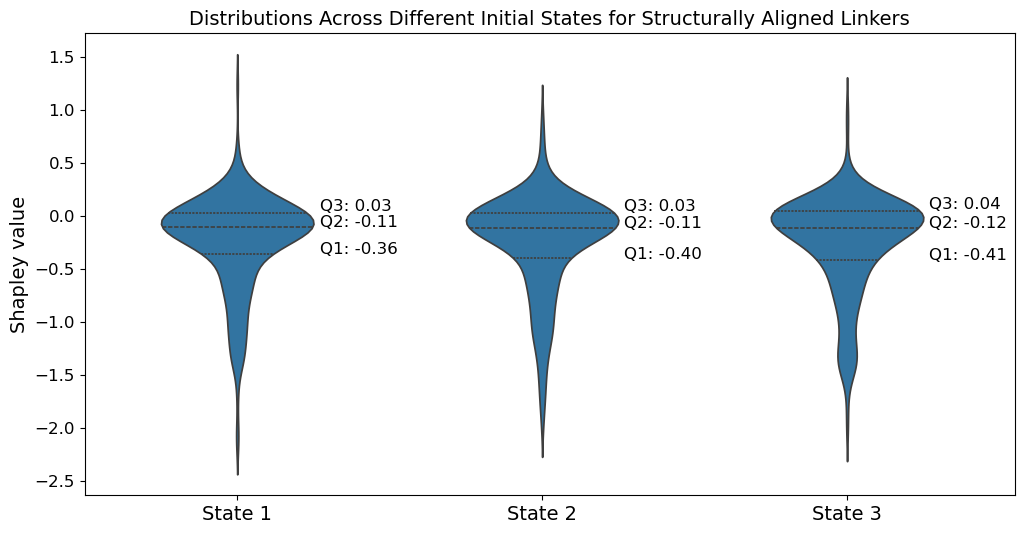

In [ ]:
# Prepare data for plotting
shapley_values_all = []
seeds_all = []
samples_all = []

for sample, shapley_values_list in shapley_values_similar_dict.items():
    for seed_index, shapley_values in enumerate(shapley_values_list):
        shapley_values_all.extend(shapley_values)
        seeds_all.extend([SEED_LIST[seed_index]] * len(shapley_values))
        samples_all.extend([sample] * len(shapley_values))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Shapley value': shapley_values_all,
    'Seed': seeds_all,
    'Sample': samples_all
})

# Plot the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)
plt.title('Distributions Across Different Initial States for Structurally Aligned Linkers', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=["State 1", "State 2", "State 3"], fontsize=14)
plt.yticks(fontsize=12)
plt.xlabel(None)
plt.ylabel('Shapley value', fontsize=14)

seed_mapping = {seed: idx for idx, seed in enumerate(SEED_LIST)}

# Compute quartiles for each seed
quartiles = plot_data.groupby('Seed')['Shapley value'].quantile([0.25, 0.5, 0.75]).unstack()

# Print quartiles on the plot
for seed in SEED_LIST:
    q25, q50, q75 = quartiles.loc[seed]
    plt.text(seed_mapping[seed] + 0.27, q25, f'Q1: {q25:.2f}', color='black', fontsize=12)
    plt.text(seed_mapping[seed] + 0.27, q50, f'Q2: {q50:.2f}', color='black', fontsize=12)
    plt.text(seed_mapping[seed] + 0.27, q75 + 0.02, f'Q3: {q75:.2f}', color='black', fontsize=12)
    plt.xlim(right=2.55)

if SAVE_PLOTS:
    plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_aligned_linkers.png", dpi=300)
    plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_aligned_linkers.pdf", dpi=300)

Plot Shapley value distribution for different the linkers

C:\Users\Mastro\AppData\Local\Temp\ipykernel_30736\2307253287.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)


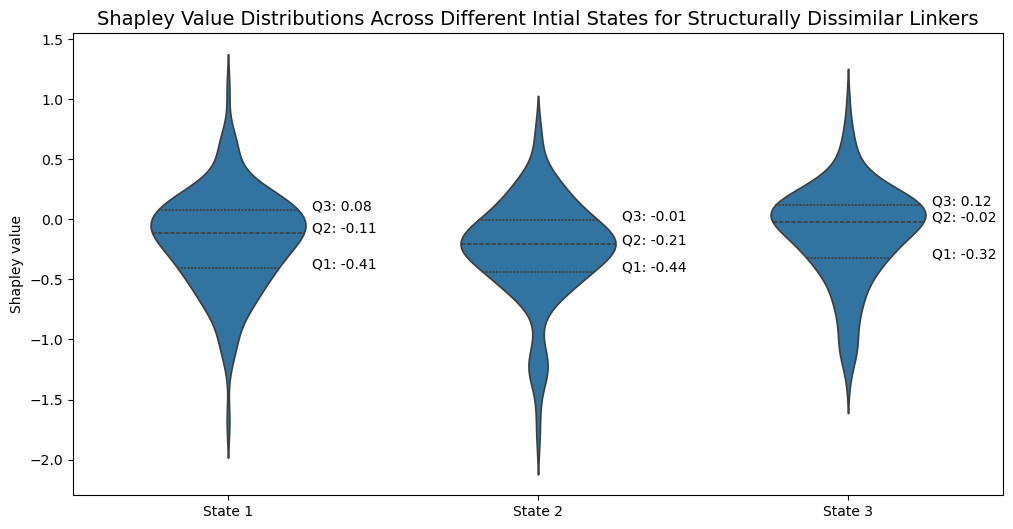

In [ ]:
# Prepare data for plotting
#get shapley values for different samples
shapley_values_all = []
seeds_all = []
samples_all = []

for sample, shapley_values_list in shapley_values_different_dict.items():
    for seed_index, shapley_values in enumerate(shapley_values_list):
        shapley_values_all.extend(shapley_values)
        seeds_all.extend([SEED_LIST[seed_index]] * len(shapley_values))
        samples_all.extend([sample] * len(shapley_values))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Shapley value': shapley_values_all,
    'Seed': seeds_all,
    'Sample': samples_all
})

# Plot the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)
plt.title('Shapley Value Distributions Across Different Intial States for Structurally Dissimilar Linkers', fontsize=14)
plt.xticks(ticks=[0, 1, 2], labels=["State 1", "State 2", "State 3"])
plt.xlabel(None)

seed_mapping = {seed: idx for idx, seed in enumerate(SEED_LIST)}

# Compute quartiles for each seed
quartiles = plot_data.groupby('Seed')['Shapley value'].quantile([0.25, 0.5, 0.75]).unstack()

# Print quartiles on the plot
for seed in SEED_LIST:
    q25, q50, q75 = quartiles.loc[seed]
    plt.text(seed_mapping[seed] + 0.27, q25, f'Q1: {q25:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q50, f'Q2: {q50:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q75, f'Q3: {q75:.2f}', color='black', fontsize=10)

if SAVE_PLOTS:
    plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_dissimilar_linkers.png", dpi=300)
    plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_dissimilar_linkers.pdf", dpi=300)

Distrubution of Shapley values for all the linkers

C:\Users\Mastro\AppData\Local\Temp\ipykernel_30736\12351633.py:22: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)


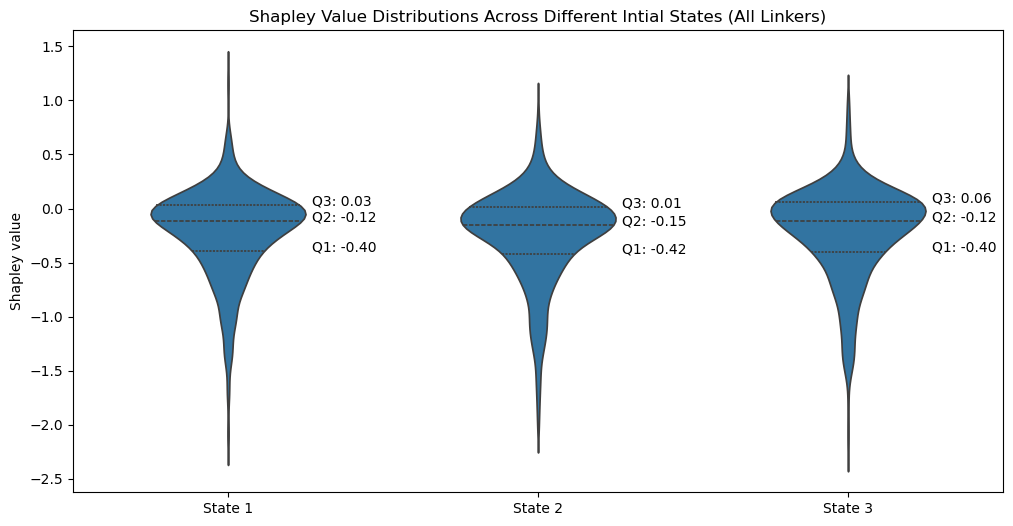

In [ ]:
# Prepare data for plotting
#get shapley values for different samples
shapley_values_all = []
seeds_all = []
samples_all = []

for sample, shapley_values_list in shapley_values_all_dict.items():
    for seed_index, shapley_values in enumerate(shapley_values_list):
        shapley_values_all.extend(shapley_values)
        seeds_all.extend([SEED_LIST[seed_index]] * len(shapley_values))
        samples_all.extend([sample] * len(shapley_values))

# Create a DataFrame for plotting
plot_data = pd.DataFrame({
    'Shapley value': shapley_values_all,
    'Seed': seeds_all,
    'Sample': samples_all
})

# Plot the violin plot
plt.figure(figsize=(12, 6))
sns.violinplot(x='Seed', y='Shapley value', data=plot_data, inner="quartile", scale="width", width=0.5)
plt.title('Shapley Value Distributions Across Different Intial States (All Linkers)')
plt.xticks(ticks=[0, 1, 2], labels=["State 1", "State 2", "State 3"])
plt.xlabel(None)

seed_mapping = {seed: idx for idx, seed in enumerate(SEED_LIST)}

# Compute quartiles for each seed
quartiles = plot_data.groupby('Seed')['Shapley value'].quantile([0.25, 0.5, 0.75]).unstack()

# Print quartiles on the plot
for seed in SEED_LIST:
    q25, q50, q75 = quartiles.loc[seed]
    plt.text(seed_mapping[seed] + 0.27, q25, f'Q1: {q25:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q50, f'Q2: {q50:.2f}', color='black', fontsize=10)
    plt.text(seed_mapping[seed] + 0.27, q75, f'Q3: {q75:.2f}', color='black', fontsize=10)

if SAVE_PLOTS:
    plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_all_linkers.png", dpi=300)
    plt.savefig(f"../results/plots/shapley_value_distrubution_analysis/distribution_all_linkers.pdf", dpi=300)

### Inspecting Shapley value significance

Inspecting difference between the Shapley values for different initial states

In [ ]:
shapley_values_chosen_seed = plot_data[plot_data['Seed'] == 42]['Shapley value'].values

Test if Shapley value center statistically different from zero

In [ ]:
alpha = 0.05
chosen_seed = 42

# One value per sample for the chosen seed (mean across atoms in that sample)
seed_idx = SEED_LIST.index(chosen_seed)
sample_level_vals = np.array([
    np.mean(shapley_values_all_dict[sample][seed_idx])
    for sample in sorted(shapley_values_all_dict.keys())
], dtype=float)

print(f"Seed {chosen_seed} | n_samples={len(sample_level_vals)}")
print(f"Mean={sample_level_vals.mean():.6f}, Median={np.median(sample_level_vals):.6f}, Std={sample_level_vals.std(ddof=1):.6f}")


# Primary inferential test: Wilcoxon signed-rank vs 0 (two-sided)
# (distribution-free; still assumes symmetry of sample-level differences)
if np.allclose(sample_level_vals, 0):
    print("All sample-level values are zero; no test can detect a difference.")
else:
    w_stat, w_p = stats.wilcoxon(sample_level_vals, zero_method="wilcox", alternative="two-sided")
    print(f"Wilcoxon signed-rank vs 0: statistic={w_stat:.6f}, p-value={w_p:.6g}")
    if w_p < alpha:
        print("Conclusion: sample-level Shapley center differs from 0.")
    else:
        print("Conclusion: no evidence that sample-level Shapley center differs from 0.")

Seed 42 | n_samples=30
Mean=-0.217613, Median=-0.217815, Std=0.111169
Wilcoxon signed-rank vs 0: statistic=3.000000, p-value=9.31323e-09
Conclusion: sample-level Shapley center differs from 0.


Test against randomicity of Shapley distribution patterns

In [ ]:
rng = np.random.default_rng(0)
B = 5000
seed_pairs = [(0, 1), (0, 2), (1, 2)]  # indices in SEED_LIST

# Observed statistic: mean Spearman correlation of |Shapley| across seed pairs and samples
obs_rhos = []
for sample in sorted(shapley_values_all_dict.keys()):
    vals = shapley_values_all_dict[sample]
    for a, b in seed_pairs:
        x = np.abs(np.asarray(vals[a], dtype=float))
        y = np.abs(np.asarray(vals[b], dtype=float))
        if len(x) == len(y) and len(x) > 2:
            rho, _ = spearmanr(x, y)
            if np.isfinite(rho):
                obs_rhos.append(rho)

obs_stat = np.mean(obs_rhos)

# Null: break atom-to-atom correspondence by permuting one seed vector within each sample
null_stats = np.empty(B, dtype=float)
for bi in range(B):
    null_rhos = []
    for sample in sorted(shapley_values_all_dict.keys()):
        vals = shapley_values_all_dict[sample]
        for a, b in seed_pairs:
            x = np.abs(np.asarray(vals[a], dtype=float))
            y = np.abs(np.asarray(vals[b], dtype=float))
            if len(x) == len(y) and len(x) > 2:
                y_perm = rng.permutation(y)
                rho, _ = spearmanr(x, y_perm)
                if np.isfinite(rho):
                    null_rhos.append(rho)
    null_stats[bi] = np.mean(null_rhos)

# One-sided p-value: observed agreement > random
p_value = (np.sum(null_stats >= obs_stat) + 1) / (B + 1)

print(f"Observed mean Spearman(|phi|) across seeds: {obs_stat:.4f}")
print(f"Permutation p-value (agreement > random): {p_value:.6g}")
if p_value < 0.05:
    print("Conclusion: Shapley patterns show non-random cross-seed structure.")
else:
    print("Conclusion: no strong evidence of cross-seed structure beyond random correspondence.")

Observed mean Spearman(|phi|) across seeds: 0.5118
Permutation p-value (agreement > random): 0.00019996
Conclusion: Shapley patterns show non-random cross-seed structure.
